# Quantum Phase Estimation (QPE) in Qiskit

Estimate the phase $\theta$ of an eigenvalue $e^{2\pi i \theta}$ of a unitary $U$, given one of its eigenvectors.

Here $U$ is a `PhaseGate(2\pi\theta)` with known $\theta = 1/4$, and its $|1\rangle$ eigenstate is prepared with an `X` gate.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PhaseGate
from qiskit_aer import AerSimulator

from qpe import build_qpe_circuit

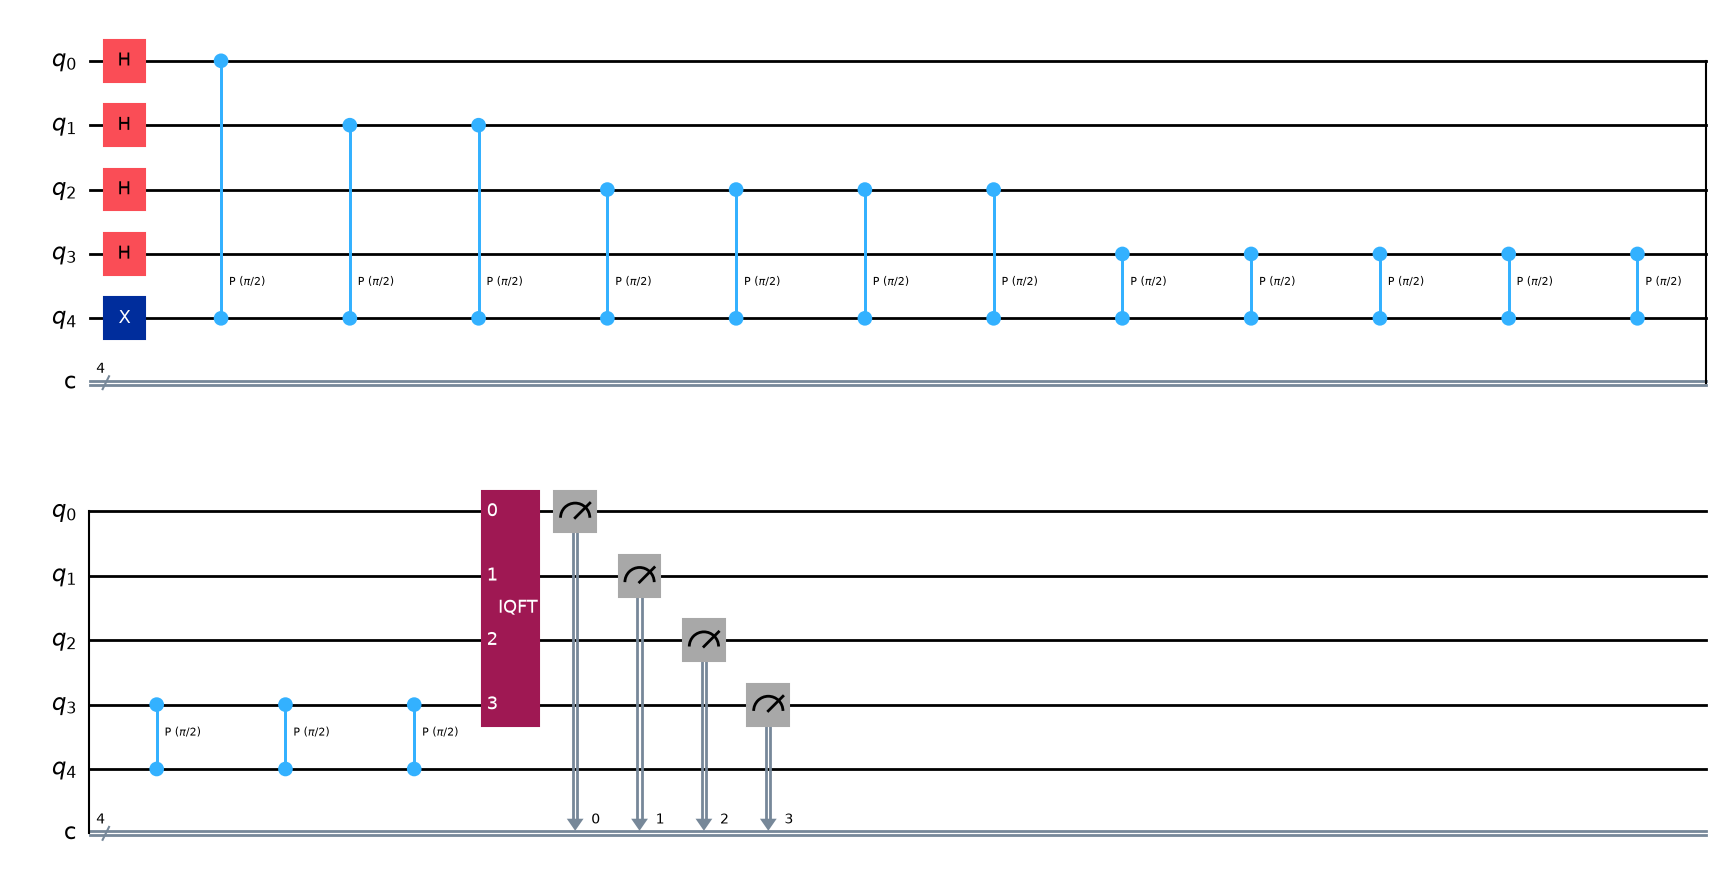

In [2]:
num_counting_qubits = 4
true_theta = 1 / 4

unitary = PhaseGate(2 * np.pi * true_theta)

qpe = build_qpe_circuit(unitary, num_counting_qubits)

qc = QuantumCircuit(num_counting_qubits + 1, num_counting_qubits)
qc.x(num_counting_qubits)  # prepare the |1> eigenstate of the phase gate
qc.compose(qpe, inplace=True)
qc.draw("mpl")

In [3]:
simulator = AerSimulator()
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=2048).result()
counts = result.get_counts()

most_likely = max(counts, key=counts.get)
estimated_theta = int(most_likely, 2) / 2 ** num_counting_qubits

print(f"true theta:      {true_theta}")
print(f"estimated theta: {estimated_theta}")

true theta:      0.25
estimated theta: 0.25


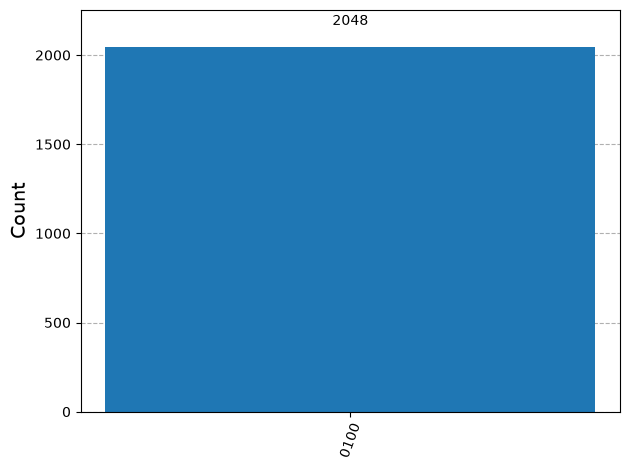

In [4]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)